In [ ]:
#STEP 1: Upload Excel dataset
from google.colab import files
uploaded = files.upload()


Saving Data Received from_Usability_Evaluation_of_a_Retail_Demand_Forecasting_Prototype.xlsx to Data Received from_Usability_Evaluation_of_a_Retail_Demand_Forecasting_Prototype.xlsx


In [ ]:
#STEP 2: Load dataset
#Reads the uploaded Excel file into Python as a dataframe for analysis.
import pandas as pd
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully
Shape: (9, 35)


,start,end,"You are invited to take part in a brief usability evaluation of a retail demand forecasting prototype developed as part of an MSc dissertation project. The purpose of this study is to assess how clearly the prototype presents forecasting outputs and how useful those outputs appear for planning and decision-making. Participation involves reviewing a small set of prototype visuals and answering a short questionnaire about their clarity, usability, and usefulness. The questionnaire should take approximately 5–10 minutes to complete. Your participation is voluntary. You may stop the questionnaire at any time before submission. Your responses will be used for academic research purposes only.","No sensitive personal information is required for this questionnaire. Responses will be treated confidentially and used only for academic analysis within the dissertation. By proceeding, you indicate that you understand the purpose of the study and are willing to take part.",Do you consent to participate in this study?,Are you currently a student of Leeds Beckett University?,Are you 18 years of age or older?,"What is your department, programme, or area of study?","SECTION B: PROTOTYPE REVIEW AND INSTRUCTIONS Please review the prototype forecasting outputs before answering the usability questions. These visuals present the retail demand forecasting system developed in this study. After reviewing them, answer the questions based on clarity, usability, and decision-support value. After reviewing all figures, please proceed to answer the questions.",You can also access the figures here:,...,_uuid,_submission_time,_validation_status,_notes,_status,_submitted_by,__version__,_tags,meta/rootUuid,_index
0,2026-04-14 00:40:36.858,2026-04-14 00:52:03.641,NaN,NaN,"Yes, I consent to participate",Yes,Yes,Compute science,NaN,NaN,...,4d3a6c52-4617-4339-8032-3044ad880ea4,2026-04-13 23:51:13,NaN,NaN,submitted_via_web,NaN,vggfj3ttcz2przcLp29vkY,NaN,uuid:4d3a6c52-4617-4339-8032-3044ad880ea4,1
1,2026-04-14 15:20:55.155,2026-04-14 15:27:21.241,NaN,NaN,"Yes, I consent to participate",Yes,Yes,Advance Computer Science,NaN,NaN,...,0bc9fcde-f9e5-4064-b025-7191751a7179,2026-04-14 14:27:12,NaN,NaN,submitted_via_web,NaN,vCyeMJVuedrgtJyEYButk4,NaN,uuid:0bc9fcde-f9e5-4064-b025-7191751a7179,2
2,2026-04-14 22:40:03.130,2026-04-14 22:43:40.875,NaN,NaN,"Yes, I consent to participate",Yes,Yes,Data Science,NaN,NaN,...,14ba1104-496b-4d76-9594-065cb8bde8e4,2026-04-14 21:43:41,NaN,NaN,submitted_via_web,NaN,vCyeMJVuedrgtJyEYButk4,NaN,uuid:14ba1104-496b-4d76-9594-065cb8bde8e4,3
3,2026-04-14 22:43:40.898,2026-04-14 22:47:38.608,NaN,NaN,"Yes, I consent to participate",Yes,Yes,Data science,NaN,NaN,...,2d3c5684-435f-481a-98a9-7bdb66fb06d6,2026-04-14 21:47:39,NaN,NaN,submitted_via_web,NaN,vCyeMJVuedrgtJyEYButk4,NaN,uuid:2d3c5684-435f-481a-98a9-7bdb66fb06d6,4
4,2026-04-14 22:40:22.679,2026-04-14 22:53:07.931,NaN,NaN,"Yes, I consent to participate",Yes,Yes,Data Science,NaN,NaN,...,e5017d15-141f-4fdd-b769-10ea8059f252,2026-04-14 21:53:07,NaN,NaN,submitted_via_web,NaN,vCyeMJVuedrgtJyEYButk4,NaN,uuid:e5017d15-141f-4fdd-b769-10ea8059f252,5


In [ ]:
#STEP 3: Clean column names
#Removes spaces and special characters from column names to prevent coding errors.
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
)

print("\nColumns:\n", df.columns.tolist())



Columns:
 ['start', 'end', 'You_are_invited_to_take_part_in_a_brief_usability_evaluation_of_a_retail_demand_forecasting_prototype_developed_as_part_of_an_MSc_dissertation_project._The_purpose_of_this_study_is_to_assess_how_clearly_the_prototype_presents_forecasting_outputs_and_how_useful_those_outputs_appear_for_planning_and_decision-making.__Participation_involves_reviewing_a_small_set_of_prototype_visuals_and_answering_a_short_questionnaire_about_their_clarity,_usability,_and_usefulness._The_questionnaire_should_take_approximately_5–10_minutes_to_complete.__Your_participation_is_voluntary._You_may_stop_the_questionnaire_at_any_time_before_submission._Your_responses_will_be_used_for_academic_research_purposes_only.', 'No_sensitive_personal_information_is_required_for_this_questionnaire._Responses_will_be_treated_confidentially_and_used_only_for_academic_analysis_within_the_dissertation._By_proceeding,_you_indicate_that_you_understand_the_purpose_of_the_study_and_are_willing_to_take_p

In [ ]:
#STEP 4: AUTO-DETECT LIKERT COLUMNS (KEY STEP)
#Identifies which columns contain survey responses (e.g., Agree, Neutral) so you don’t have to manually select them.

likert_options = [
    "Strongly Disagree",
    "Disagree",
    "Neutral",
    "Agree",
    "Strongly Agree"
]

likert_cols = []

for col in df.columns:
    unique_vals = df[col].dropna().unique()
    if any(val in likert_options for val in unique_vals):
        likert_cols.append(col)

print("\nDetected Likert Columns:\n", likert_cols)




Detected Likert Columns:
 ['The_forecast_outputs_were_clear_and_easy_to_understand.', 'The_charts_and_visualisations_were_easy_to_interpret.', 'The_comparison_between_actual_and_predicted_sales_was_presented_clearly.', 'The_demand-level_categories_were_useful_for_understanding_forecast_results.', 'The_store-level_summaries_were_helpful_for_interpreting_operational_performance.', 'The_prototype_presented_information_in_a_way_that_would_support_planning_or_decision-making.', 'The_prototype_interface_and_output_structure_were_easy_to_follow.', 'The_forecasting_results_appeared_meaningful_and_practically_relevant.', 'I_would_find_a_system_like_this_useful_in_a_retail_decision-support_context.', 'Overall,_the_prototype_was_usable_and_understandable.']


In [ ]:
#STEP 5: Convert to numeric
#Transforms text responses (e.g., “Agree”) into numbers (e.g., 4) so statistical analysis can be performed.
likert_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

df_numeric = df.copy()
df_numeric[likert_cols] = df_numeric[likert_cols].replace(likert_map)


/tmp/ipykernel_10082/1288660184.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric[likert_cols] = df_numeric[likert_cols].replace(likert_map)


In [ ]:
#STEP 6: Summary statistics
#Generates descriptive statistics (mean, min, max, etc.) for each usability question.

summary = df_numeric[likert_cols].describe().T
print(summary)


                                                    count      mean       std  \
The_forecast_outputs_were_clear_and_easy_to_und...    9.0  3.111111  1.452966   
The_charts_and_visualisations_were_easy_to_inte...    9.0  3.111111  1.536591   
The_comparison_between_actual_and_predicted_sal...    9.0  3.666667  1.581139   
The_demand-level_categories_were_useful_for_und...    9.0  3.111111  1.364225   
The_store-level_summaries_were_helpful_for_inte...    9.0  3.333333  1.581139   
The_prototype_presented_information_in_a_way_th...    9.0  3.111111  1.452966   
The_prototype_interface_and_output_structure_we...    9.0  2.888889  1.364225   
The_forecasting_results_appeared_meaningful_and...    9.0  3.222222  1.394433   
I_would_find_a_system_like_this_useful_in_a_ret...    9.0  3.333333  1.414214   
Overall,_the_prototype_was_usable_and_understan...    9.0  3.222222  1.481366   

                                                    min  25%  50%  75%  max  
The_forecast_outputs_were_clea

In [ ]:
#STEP 7: Mean scores (Calculates the average rating for each usability dimension to show overall user perception)
mean_scores = df_numeric[likert_cols].mean().sort_values(ascending=False)
print("\nMean Scores:\n", mean_scores)



Mean Scores:
 The_comparison_between_actual_and_predicted_sales_was_presented_clearly.                        3.666667
The_store-level_summaries_were_helpful_for_interpreting_operational_performance.                3.333333
I_would_find_a_system_like_this_useful_in_a_retail_decision-support_context.                    3.333333
The_forecasting_results_appeared_meaningful_and_practically_relevant.                           3.222222
Overall,_the_prototype_was_usable_and_understandable.                                           3.222222
The_forecast_outputs_were_clear_and_easy_to_understand.                                         3.111111
The_charts_and_visualisations_were_easy_to_interpret.                                           3.111111
The_demand-level_categories_were_useful_for_understanding_forecast_results.                     3.111111
The_prototype_presented_information_in_a_way_that_would_support_planning_or_decision-making.    3.111111
The_prototype_interface_and_output_struc

In [ ]:
#STEP 8: Frequency tables (Counts how many respondents selected each response option (e.g., how many chose “Agree”).

for col in likert_cols:
    print(f"\nDistribution for {col}:\n")
    print(df[col].value_counts())



Distribution for The_forecast_outputs_were_clear_and_easy_to_understand.:

The_forecast_outputs_were_clear_and_easy_to_understand.
Agree                4
Strongly Disagree    2
Strongly Agree       1
Neutral              1
Disagree             1
Name: count, dtype: int64

Distribution for The_charts_and_visualisations_were_easy_to_interpret.:

The_charts_and_visualisations_were_easy_to_interpret.
Strongly Agree       2
Agree                2
Strongly Disagree    2
Neutral              2
Disagree             1
Name: count, dtype: int64

Distribution for The_comparison_between_actual_and_predicted_sales_was_presented_clearly.:

The_comparison_between_actual_and_predicted_sales_was_presented_clearly.
Agree                4
Strongly Agree       3
Strongly Disagree    2
Name: count, dtype: int64

Distribution for The_demand-level_categories_were_useful_for_understanding_forecast_results.:

The_demand-level_categories_were_useful_for_understanding_forecast_results.
Agree                3
Ne

/tmp/ipykernel_10082/1197081438.py:10: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


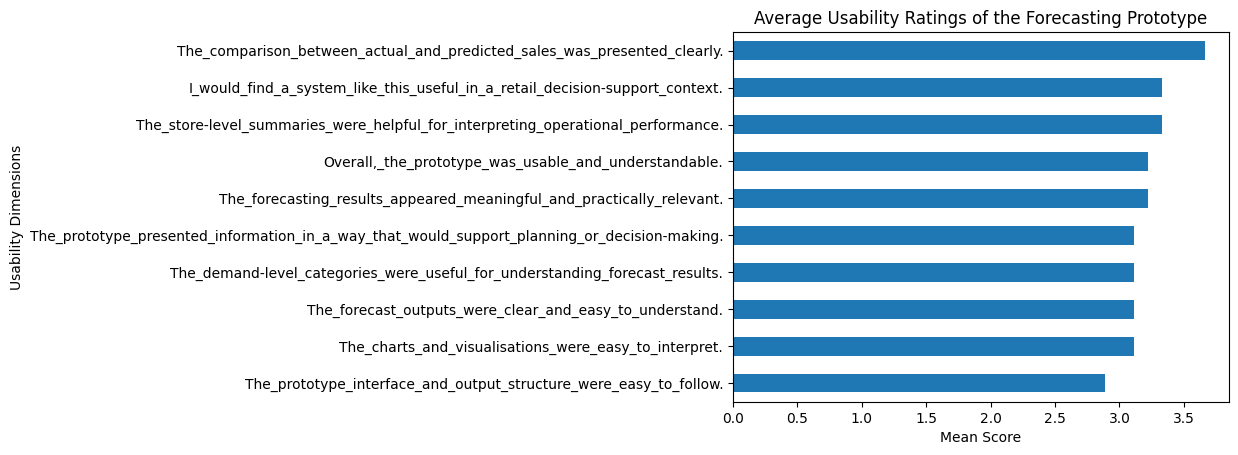

In [ ]:
#STEP 9: Chart (Mean scores) - Creates a visual bar chart showing how each usability aspect was rated on average.

import matplotlib.pyplot as plt
mean_scores.sort_values().plot(kind='barh')

plt.title("Average Usability Ratings of the Forecasting Prototype")
plt.xlabel("Mean Score")
plt.ylabel("Usability Dimensions")

plt.tight_layout()
plt.show()

In [ ]:
#STEP 10: Overall usability score- Combines all responses into a single score per participant to measure overall system usability.

df_numeric["Overall_Usability"] = df_numeric[likert_cols].mean(axis=1)

print(df_numeric["Overall_Usability"].describe())


count    9.000000
mean     3.211111
std      1.408407
min      1.000000
25%      2.500000
50%      3.800000
75%      4.000000
max      5.000000
Name: Overall_Usability, dtype: float64
